Divide & Conquer Times: [0.0002880096435546875, 0.0008168220520019531, 0.0045740604400634766, 0.0017766952514648438]


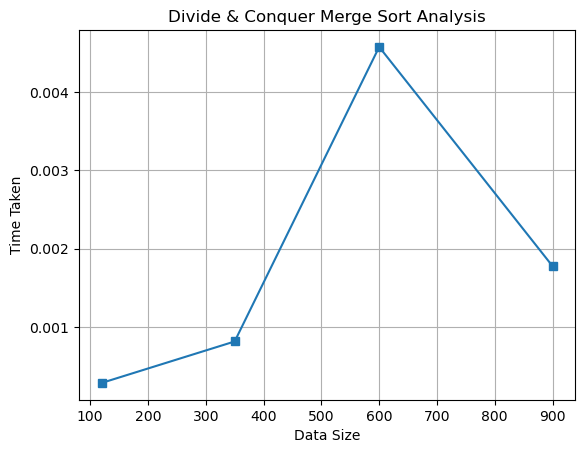

In [1]:
import time
import random
import matplotlib.pyplot as plt
import itertools

def merge_sort_dc(data):
    if len(data) <= 1:
        return data
    
    center = len(data) // 2
    first_half = merge_sort_dc(data[:center])
    second_half = merge_sort_dc(data[center:])
    
    return combine(first_half, second_half)

def combine(a, b):
    merged = []
    x = y = 0
    
    while x < len(a) and y < len(b):
        if a[x] < b[y]:
            merged.append(a[x])
            x += 1
        else:
            merged.append(b[y])
            y += 1
    
    merged += a[x:]
    merged += b[y:]
    
    return merged

input_sizes = [120, 350, 600, 900]
dc_times = []

for n in input_sizes:
    test_data = [random.randint(10, 5000) for _ in range(n)]
    
    t1 = time.time()
    merge_sort_dc(test_data)
    t2 = time.time()
    
    dc_times.append(t2 - t1)

print("Divide & Conquer Times:", dc_times)

plt.plot(input_sizes, dc_times, marker='s')
plt.title("Divide & Conquer Merge Sort Analysis")
plt.xlabel("Data Size")
plt.ylabel("Time Taken")
plt.grid()
plt.show()

Merge Sort: [0.000942230224609375, 0.002791166305541992, 0.003152132034301758, 0.0014922618865966797]
Bubble Sort: [0.0022916793823242188, 0.014366865158081055, 0.02853536605834961, 0.04729795455932617]


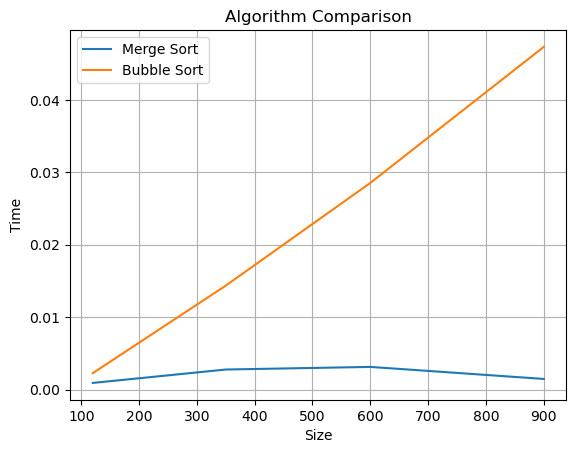

In [2]:
def simple_bubble(arr):
    n = len(arr)
    for i in range(n):
        for j in range(n - i - 1):
            if arr[j] > arr[j+1]:
                arr[j], arr[j+1] = arr[j+1], arr[j]
    return arr

sizes = [120, 350, 600, 900]
dc_list = []
bubble_list = []

for n in sizes:
    values = [random.randint(1, 1000) for _ in range(n)]
    
    t1 = time.time()
    merge_sort_dc(values.copy())
    dc_list.append(time.time() - t1)
    
    t2 = time.time()
    simple_bubble(values.copy())
    bubble_list.append(time.time() - t2)

print("Merge Sort:", dc_list)
print("Bubble Sort:", bubble_list)

plt.plot(sizes, dc_list, label="Merge Sort")
plt.plot(sizes, bubble_list, label="Bubble Sort")
plt.title("Algorithm Comparison")
plt.xlabel("Size")
plt.ylabel("Time")
plt.legend()
plt.grid()
plt.show()

In [3]:
def greedy_knapsack(w, v, cap):
    items = [(v[i]/w[i], w[i], v[i]) for i in range(len(w))]
    items.sort(reverse=True)
    
    final_value = 0
    
    for ratio, weight, value in items:
        print(f"Selected item ratio: {round(ratio,2)}")
        
        if cap >= weight:
            cap -= weight
            final_value += value
        else:
            final_value += ratio * cap
            break
    
    return final_value

weights = [5, 15, 25]
values = [50, 90, 140]
capacity = 40

print("Final Profit:", greedy_knapsack(weights, values, capacity))



Selected item ratio: 10.0
Selected item ratio: 6.0
Selected item ratio: 5.6
Final Profit: 252.0


In [4]:
def dp_knapsack(capacity, weights, profits):
    n = len(profits)
    table = [[0]*(capacity+1) for _ in range(n+1)]
    
    for i in range(1, n+1):
        for w in range(1, capacity+1):
            if weights[i-1] <= w:
                table[i][w] = max(
                    profits[i-1] + table[i-1][w - weights[i-1]],
                    table[i-1][w]
                )
            else:
                table[i][w] = table[i-1][w]
    
    return table

weights = [5, 15, 25]
profits = [50, 90, 140]
capacity = 40

start = time.time()
dp_result = dp_knapsack(capacity, weights, profits)
end = time.time()

print("Execution Time:", end-start)
print("DP Table:")

for row in dp_result:
    print(row)

print("Maximum Profit:", dp_result[len(profits)][capacity])

Execution Time: 0.0003952980041503906
DP Table:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50]
[0, 0, 0, 0, 0, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 90, 90, 90, 90, 90, 140, 140, 140, 140, 140, 140, 140, 140, 140, 140, 140, 140, 140, 140, 140, 140, 140, 140, 140, 140, 140]
[0, 0, 0, 0, 0, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 90, 90, 90, 90, 90, 140, 140, 140, 140, 140, 140, 140, 140, 140, 140, 190, 190, 190, 190, 190, 190, 190, 190, 190, 190, 230]
Maximum Profit: 230


In [5]:
def tsp_solver(matrix):
    size = len(matrix)
    cities = list(range(size))
    
    best_cost = float('inf')
    
    for path in itertools.permutations(cities[1:]):
        cost = 0
        start = 0
        
        for next_city in path:
            cost += matrix[start][next_city]
            start = next_city
        
        cost += matrix[start][0]
        
        best_cost = min(best_cost, cost)
    
    return best_cost

matrix = [
    [0, 12, 18, 25],
    [12, 0, 30, 20],
    [18, 30, 0, 28],
    [25, 20, 28, 0]
]

start = time.time()
answer = tsp_solver(matrix)
end = time.time()

print("Optimal Route Cost:", answer)
print("Time Taken:", end-start)

Optimal Route Cost: 78
Time Taken: 0.00016546249389648438
